In [1]:
import sys
!conda install --yes --prefix {sys.prefix} -c conda-forge sympy
#!{sys.executable} -m pip install webdriver_manager 

Solving environment: ...working... done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
  current version: 23.7.4
  latest version: 24.3.0

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=24.3.0




Here we create a label, x, to refer to the number 1. Then, when we write the statement x + x + 1, it’s evaluated for us, and the result is 3. What if you wanted the result in terms of the symbol x? That is, if instead of 3, you wanted Python to tell you that the result is 2x + 1? You couldn’t just write
x + x + 1 without the statement x = 1 because Python wouldn’t know what x refers to.

In [2]:
x = 1
x + x + 1

3

Use the symbol functin to make symbols.

In [3]:
from sympy import Symbol
import matplotlib
x = Symbol('x')
y = Symbol('y')

In [4]:
s = x*y + x*y
s

2*x*y

In [5]:
x + x + 1

2*x + 1

In [6]:
a = Symbol('x')
a + a + 1

2*x + 1

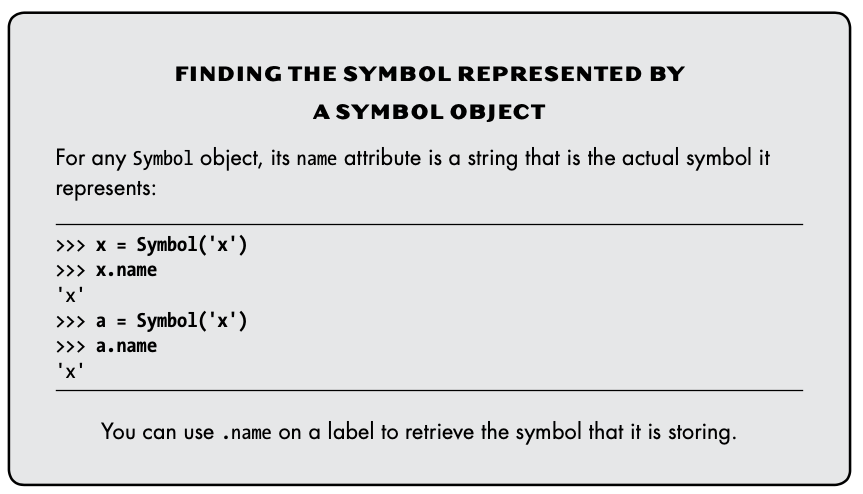

In [7]:
x = Symbol('x')
y = Symbol('y')
z = Symbol('z')

In [11]:
#Faster way to create symbols.

In [12]:
from sympy import symbols
x,y,z = symbols('x,y,z')

In [13]:
s = x*y + x*y + z 
s

2*x*y + z

In [14]:
p = x*(x + x)
p

2*x**2

In [15]:
p = (x + 2)*(x + 3)
p

(x + 2)*(x + 3)

The factor() function decomposes an expression into its factors, and the
expand() function expands an expression, expressing it as a sum of individual terms. Let’s test out these functions with the basic algebraic identity 22
x − y = (x + y)(x − y). The left side of the identity is the expanded version, and the right side depicts the corresponding factorization. Because we have two symbols in the identity, we’ll create two Symbol objects:

In [16]:
from sympy import factor
expr = x**2 - y**2
print(expr)
factor(expr)

x**2 - y**2


(x - y)*(x + y)

You can do a reverse operation

In [17]:
from sympy import expand
factors = factor(expr)
print(factors)
expand(factors)

(x - y)*(x + y)


x**2 - y**2

We store the factorized expression in a new label, factors, and then call the expand() function with it. When we do this, we receive the original expression we started with. Let’s try it with the more complicated identity x3 + 3x2y + 3xy2 + y3 = (x + y)3:

In [18]:
expr = x**3 + 3*x**2*y + 3*x*y**2 + y**3
print(expr)
factors = factor(expr)
factors

x**3 + 3*x**2*y + 3*x*y**2 + y**3


(x + y)**3

In [19]:
expand(factors)

x**3 + 3*x**2*y + 3*x*y**2 + y**3

### Substituting values

In [20]:
x = Symbol('x')
y = Symbol('y')
x*x + x*y + x*y + y*y

x**2 + 2*x*y + y**2

If you want to evaluate this expression, you can substitute numbers in for the symbols using the subs() method

In [21]:
expr = x*x + x*y + x*y + y*y
print(expr)
res = expr.subs({x:1, y:2})
res

x**2 + 2*x*y + y**2


9

You can also express one symbol in terms of another and substitute accordingly, using the subs() method. For example, if you knew that
x = 1 − y, here’s how you could evaluate the preceding expression:

In [22]:
expr.subs({x:1-y})

y**2 + 2*y*(1 - y) + (1 - y)**2

If you want the result to be simplified further—for example, if there are terms that cancel each other out, we can use SymPy’s simplify() function, as follows:

In [23]:
expr_subs = expr.subs({x:1-y})
from sympy import simplify
simplify(expr_subs)

1

In [25]:
from sympy import sympify
expr = input('Enter a mathematical expression: ')
expr = sympify(expr)
expr

Enter a mathematical expression: x**2


x**2

### Solving equations

SymPy’s solve() function can be used to find solutions to equations. When you input an expression with a symbol representing a variable, such as x, solve() calculates the value of that symbol. This function always makes its calculation by assuming the expression you enter is equal to zero that is, it prints the value that, when substituted for the symbol, makes the entire expression equal zero. Let’s start with the simple equation x − 5 = 7. If we want to use solve() to find the value of x, we first have to make one side of the equation equal zero (x − 5 − 7 = 0). Then, we’re ready to use solve(), as follows:

In [26]:
from sympy import Symbol, solve
x = Symbol('x')
expr = x - 5 - 7
solve(expr)

[12]

Quadratic equations solving.

In [27]:
from sympy import solve
x = Symbol('x')
expr = x**2 + 5*x + 4
solve(expr, dict=True)

[{x: -4}, {x: -1}]

In [28]:
x = Symbol('x')
a = Symbol('a')
b = Symbol('b')
c = Symbol('c')
expr = a*x*x + b*x + c
solve(expr, x, dict=True)

[{x: (-b - sqrt(-4*a*c + b**2))/(2*a)}, {x: (-b + sqrt(-4*a*c + b**2))/(2*a)}]

In [29]:
from sympy import Symbol, solve, pprint
s = Symbol('s')
u = Symbol('u')
t = Symbol('t')
a = Symbol('a')
expr = u*t + (1/2)*a*t*t - s
t_expr = solve(expr,t, dict=True)
t_expr

[{t: (-u - 1.4142135623731*sqrt(a*s + 0.5*u**2))/a},
 {t: (-u + 1.4142135623731*sqrt(a*s + 0.5*u**2))/a}]

### Solving a System of Linear Equations

In [30]:
x = Symbol('x')
y = Symbol('y')
expr1 = 2*x + 3*y - 6
expr2 = 3*x + 3*y -12
solve((expr1, expr2), dict=True)

[{x: 6, y: -2}]

In [32]:
#verify the solution.

In [33]:
soln = solve((expr1, expr2), dict=True)
soln = soln[0]
print(expr1.subs({x:soln[x], y:soln[y]}))
print(expr2.subs({x:soln[x], y:soln[y]}))

0
0


### Plotting using symPy

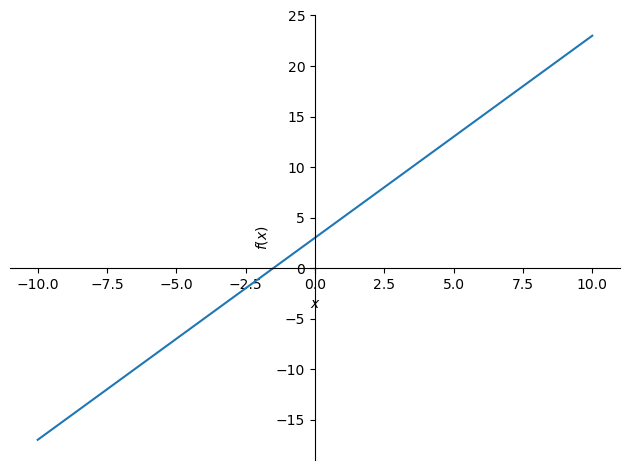

In [34]:
from sympy.plotting import plot
from sympy import Symbol
x = Symbol('x')
plot(2*x+3)

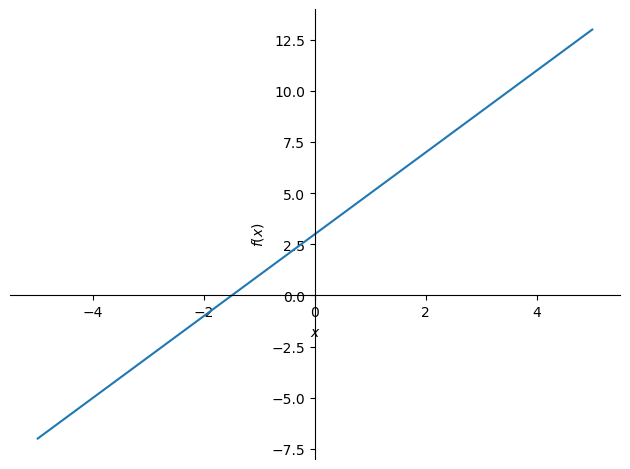

In [35]:
plot((2*x + 3), (x, -5, 5)) #reziai 

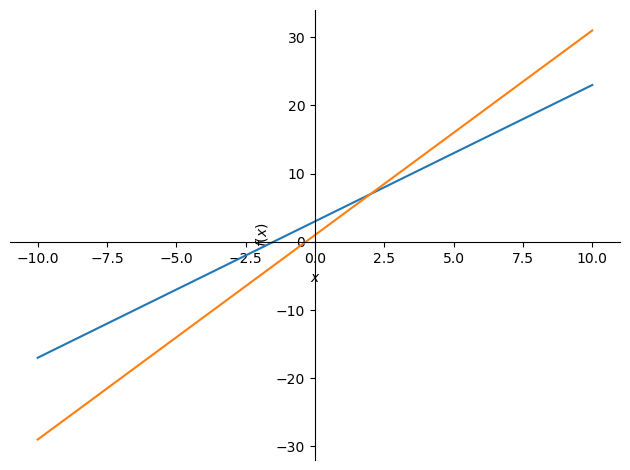

In [36]:
from sympy.plotting import plot
from sympy import Symbol
x = Symbol('x')
plot(2*x+3, 3*x+1)

We import the Limit and Symbol classes, as well as S, which is a special SymPy class that contains the definition of infinity (positive and negative) and other special values. Then at we create a symbol object, x, to represent x. We create the Limit object at, passing it three arguments: 1/x, the variable x, and finally the value at which we want to calculate the function’s limit (infinity, given by S.Infinity).
The result is returned as an unevaluated object with the oo symbol denoting positive infinity and the dir='-' symbol specifying that we are approaching the limit from the negative side.
To find the value of the limit, we use the doit() method

### LIMITS

In [37]:
from sympy import Limit, Symbol, S
x = Symbol('x')
Limit(1/x, x, S.Infinity)

Limit(1/x, x, oo, dir='-')

In [39]:
l = Limit(1/x, x, S.Infinity)
l.doit()

0

In [40]:
Limit(1/x, x, 0, dir='-').doit()

-oo

In [41]:
Limit(1/x, x, 0, dir='+').doit()

oo

### DERIVATIVES

The derivative of a function y = f(x) expresses the rate of change in the dependent variable, y, with respect to the independent variable, x. It’s denoted as either f′(x) or dy/dx. We can find the derivative of a function by creating an object of the Derivative class. Let’s use the previous function representing the motion of a car as an example:

In [42]:
from sympy import Symbol, Derivative
t = Symbol('t')
St = 5*t**2 + 2*t + 8
Derivative(St, t)

Derivative(5*t**2 + 2*t + 8, t)

In [43]:
d = Derivative(St, t)
d.doit()

10*t + 2

In [44]:
d.doit().subs({t:1})

12

In [45]:
from sympy import Derivative, Symbol
x = Symbol('x')
f = (x**5 + x**3 + x)*(x**2+x)
f
Derivative(f, x).doit()

(2*x + 1)*(x**5 + x**3 + x) + (x**2 + x)*(5*x**4 + 3*x**2 + 1)

In [46]:
from sympy import Derivative, Symbol
x = Symbol('x')
f = (x**3 + x**2 + x)*(x**2+x)
Derivative(f, x).doit()

(2*x + 1)*(x**3 + x**2 + x) + (x**2 + x)*(3*x**2 + 2*x + 1)

In [47]:
from sympy import Derivative, Symbol
x = Symbol('x')
f = 2*x*y + x*y**2
Derivative(f, x).doit()

y**2 + 2*y

In [49]:
from sympy import Derivative, Symbol
x = Symbol('x')
f = 2*x*y + x*y**2
Derivative(f, y).doit()

2*x*y + 2*x

#### MINIMA MAXIMA

In [48]:
from sympy import Symbol, solve, Derivative
x = Symbol('x')
f = x**5 - 30*x**3 + 50*x
d1 = Derivative(f, x).doit()
critical_points = solve(d1)
critical_points

[-sqrt(9 - sqrt(71)),
 sqrt(9 - sqrt(71)),
 -sqrt(sqrt(71) + 9),
 sqrt(sqrt(71) + 9)]

### INTEGRALS

In [50]:
from sympy import Integral, Symbol
x = Symbol('x')
k = Symbol('k')
Integral(k*x, x)

Integral(k*x, x)

In [51]:
Integral(k*x, x).doit()

k*x**2/2

In [52]:
Integral(k*x, (x, 0, 2)).doit()

2*k

In [53]:
from sympy import Integral, Symbol
import sympy
import numpy as np
import math
x = Symbol('x')

Integral(1/sympy.sqrt((x-2)), x)

Integral(1/sqrt(x - 2), x)

In [54]:
Integral(1/sympy.sqrt((x-2)), x).doit()

2*sqrt(x - 2)

In [55]:
from sympy import Integral, Symbol
import math
x = Symbol('x')
Integral( (1)/(x**3 +x), x)

Integral(1/(x**3 + x), x)

In [56]:
Integral((1)/(x**3 +x), (x,1,2)).doit()

-log(5)/2 + 3*log(2)/2

In [57]:
- (math.log(5))/2 + 3*(math.log(2))/2

0.23500181462286773

In [58]:
from sympy import factor
expr = x**2 - 5*x +6
factor(expr)

(x - 3)*(x - 2)

In [59]:
from sympy import pdiv
from sympy.abc import x
pdiv(x**4+9*x**2+x+2, x**2+9)

(x**2, x + 2)

### PARTIAL FRACTION DECOMPOSITION

In [60]:
from sympy import apart
f = (4*x**3-27*x**2+5*x-32)/(30*x**5-13*x**4+50*x**3-286*x**2-299*x-70)
f

(4*x**3 - 27*x**2 + 5*x - 32)/(30*x**5 - 13*x**4 + 50*x**3 - 286*x**2 - 299*x - 70)

In [61]:
apart(f)

(22098*x + 48935)/(260015*(x**2 + x + 5)) + 24110/(4879*(5*x + 2)) - 9438/(80155*(3*x - 7)) - 668/(323*(2*x + 1))

### PROBABILITY

Working with the normal distirbution

$$ f(x) = \frac{1}{\sigma\sqrt2\pi}e^{\frac{1}{2}(\frac{x-\mu}{\sigma})^2}   $$

In [62]:
from sympy import Symbol, exp, sqrt, pi, Integral
x = Symbol('x')
p = exp(-(x - 10)**2/2)/sqrt(2*pi)
Integral(p, (x, 11, 12)).doit().evalf()

0.135905121983278

In [63]:
import scipy.stats
scipy.stats.norm(0, 1)
scipy.stats.norm(0, 1).pdf(0)
scipy.stats.norm(0, 1).cdf(0)

0.5

Resting breathing rates for college-age students are approximately normally distributed with
mean 12 and standard deviation 2.3 breaths per minute. What fraction of all college-age students
have breathing rates in the following intervals?

a) 9.7 to 14.3 breaths per minute

b) 7.4 to 16.6 breaths per minute

c) 9.7 to 16.6 breaths per minute

d) Less than 5.1 or more than 18.9 breaths per minute

In [64]:
from sympy import Symbol, exp, sqrt, pi, Integral
x = Symbol('x')
mean = 12
sigma = 2.3
p = exp((-1/2) * ((x - mean)/sigma)**2)    / (sigma * sqrt(2*pi))
Integral(p, (x,  9.7, 14.3)).doit().evalf()

0.682689492137086

In [65]:
scipy.stats.norm(12, 2.3).cdf(14.3) - scipy.stats.norm(12, 2.3).cdf(9.7)

0.6826894921370861

Weekly maintenance costs for a factory, recorded over a long period of time and adjusted
for inflation, tend to have an approximately normal distribution with an average of 420 dollars
and a standard deviation of 30 dollars. If 450 dollars are budgeted for next week, what is an approximate probability that this budgeted figure will be exceeded?

In [66]:
1 - scipy.stats.norm(420, 30).cdf(450)

0.15865525393145707

In [67]:
If X is a normal random variable with parameters μ = 3 and var = 9, find
(a) P{2 < X < 5}; (b) P{X > 0}; (c) P{|X − 3| > 6}.

SyntaxError: invalid character '−' (U+2212) (3432644791.py, line 2)

In [68]:
scipy.stats.norm(3, 3).cdf(5) - scipy.stats.norm(3, 3).cdf(2)

0.3780661222713134

### UNIFORM DISTIRBUTION

$$ f(x) = \begin{cases} 
      \frac{1}{b - a} & \text{if } a \leq x \leq b \\
      0 & \text{otherwise} 
   \end{cases}


If X is uniformly distributed over (0, 10), calculate the probability that (a) X < 3,
(b) X > 6, and (c) 3 < X < 8.

In [69]:
scipy.stats.uniform(0, 10).cdf(3)

0.3

Buses arrive at a specified stop at 15-minute intervals starting at 7 a.m. That is, they
arrive at 7, 7:15, 7:30 and so on. If a passenger arrives at the stop at a time that
is uniformly distributed between 7 and 7:30, find the probability that he waits 
(a) less than 5 minutes for a bus;
(b) more than 10 minutes for a bus.

SOLUTION. Let X denote the number of minutes past 7 that the passenger arrives at
the stop. Since X is a uniform random variable over the interval (0, 30), it follows
that the passenger will have to wait less than 5 minutes if (and only if) he arrives
between 7:10 and 7:15 or between 7:25 and 7:30. Hence, the desired probability for
part (a) is

In [70]:
a_1 = scipy.stats.uniform(0, 30).cdf(15) - scipy.stats.uniform(0, 30).cdf(10) 
a_2 = scipy.stats.uniform(0, 30).cdf(30) - scipy.stats.uniform(0, 30).cdf(25) 
a_1 + a_2

0.3333333333333333

## BINOMIAL RANDOM VARIABLE

$$ P_x = {n\choose k} p^kq^{n-k}$$

It is known that screws produced by a certain company will be defective with probability
.01, independently of one another. The company sells the screws in packages
of 10 and offers a money-back guarantee if more than 1 of the 10 screws is defective.
What proportion of packages sold must the company replace?

In [71]:
from scipy.stats import binom
#calculate binomial probability
result = binom.pmf(k=1, n=10, p=0.01)
#Print the result
print("Binomial Probability: ",result)

Binomial Probability:  0.091351724748364


In [72]:
result = binom.pmf(k=0, n=10, p=0.01)
#Print the result
print("Binomial Probability: ",result)

Binomial Probability:  0.9043820750088041


In [73]:
1 - (0.09135 + 0.90438)

0.004269999999999996